In [2]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import torch
from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
from datasets import Dataset
import evaluate
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
import zipfile

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Extract the zip file if needed
zip_path = "fr-tr.txt.zip"
extract_dir = "dataset"

if not os.path.exists(extract_dir):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete!")
else:
    print(f"Dataset directory '{extract_dir}' already exists.")

# Find the data files in the extracted directory
print("\nLooking for data files...")
data_files = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        full_path = os.path.join(root, file)
        data_files.append(full_path)
        print(f"Found: {full_path}")

# Load the parallel corpus files
# Look for files ending with .fr and .tr
french_file = None
turkish_file = None

for file in data_files:
    if file.endswith('.fr') or file.endswith('.FR'):
        french_file = file
        print(f"\n✓ French file identified: {file}")
    elif file.endswith('.tr') or file.endswith('.TR'):
        turkish_file = file
        print(f"✓ Turkish file identified: {file}")

# If still not found, look for files with language codes in the name
if not french_file or not turkish_file:
    print("\nSearching by filename pattern...")
    for file in data_files:
        filename = os.path.basename(file).lower()
        if 'fr-tr.fr' in filename or 'fr.tr.fr' in filename:
            french_file = file
            print(f"✓ French file found: {file}")
        elif 'fr-tr.tr' in filename or 'fr.tr.tr' in filename:
            turkish_file = file
            print(f"✓ Turkish file found: {file}")

if not french_file or not turkish_file:
    raise FileNotFoundError(
        f"Could not find parallel corpus files!\n"
        f"French file: {french_file}\n"
        f"Turkish file: {turkish_file}\n"
        f"Available files: {data_files}"
    )

# Load the data
print(f"\nLoading French sentences from: {french_file}")
with open(french_file, 'r', encoding='utf-8') as f:
    french_sentences = [line.strip() for line in f if line.strip()]

print(f"Loading Turkish sentences from: {turkish_file}")
with open(turkish_file, 'r', encoding='utf-8') as f:
    turkish_sentences = [line.strip() for line in f if line.strip()]

# Create a DataFrame
print(f"\nTotal French sentences: {len(french_sentences)}")
print(f"Total Turkish sentences: {len(turkish_sentences)}")

# Make sure both have the same length
min_len = min(len(french_sentences), len(turkish_sentences))
combined_df = pd.DataFrame({
    'french': french_sentences[:min_len],
    'turkish': turkish_sentences[:min_len]
})

print(f"\nCombined dataset size: {len(combined_df)}")

# Custom split: 80% train, 10% validation, 10% test
# (You can adjust these ratios)
print("\nCreating custom train/val/test split (80/10/10)...")
train_custom, temp = train_test_split(combined_df, test_size=0.2, random_state=42)
val_custom, test_custom = train_test_split(temp, test_size=0.5, random_state=42)

print(f"\nCustom split sizes:")
print(f"Train: {len(train_custom)}")
print(f"Validation: {len(val_custom)}")
print(f"Test: {len(test_custom)}")

# Save the splits
print("\nSaving data splits...")
os.makedirs('data', exist_ok=True)
train_custom.to_csv('data/train.csv', index=False)
val_custom.to_csv('data/val.csv', index=False)
test_custom.to_csv('data/test.csv', index=False)

print("Data saved to 'data/' directory")

Extracting fr-tr.txt.zip...
Extraction complete!

Looking for data files...
Found: dataset/TED2020.fr-tr.fr
Found: dataset/TED2020.fr-tr.tr
Found: dataset/LICENSE
Found: dataset/README
Found: dataset/TED2020.fr-tr.xml

✓ French file identified: dataset/TED2020.fr-tr.fr
✓ Turkish file identified: dataset/TED2020.fr-tr.tr

Loading French sentences from: dataset/TED2020.fr-tr.fr
Loading Turkish sentences from: dataset/TED2020.fr-tr.tr

Total French sentences: 368006
Total Turkish sentences: 368006

Combined dataset size: 368006

Creating custom train/val/test split (80/10/10)...

Custom split sizes:
Train: 294404
Validation: 36801
Test: 36801

Saving data splits...
Data saved to 'data/' directory


In [5]:
train_df = pd.read_csv('data/train.csv')
val_df = pd.read_csv('data/val.csv')
test_df = pd.read_csv('data/test.csv')
# train_df = train_df.sample(frac=0.5, random_state=42)  # Use 50% of data

print(f"Train set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

# Show sample
print("\nSample from test set:")
for i in range(2):
    print(f"\n[{i+1}]")
    print(f"French: {test_df.iloc[i]['french']}")
    print(f"Turkish: {test_df.iloc[i]['turkish']}")

Train set: 294404 samples
Validation set: 36801 samples
Test set: 36801 samples

Sample from test set:

[1]
French: La seule chose qui l'a sauvé fut le fait qu'il avait participé.
Turkish: Onu kurtaran tek şey, maçın parçası olduğu gerçeğiydi.

[2]
French: Comment appréhender tout ça et agir concrètement?
Turkish: Tüm bunları alıp bunlarla ilgili gerçekten ne yapabiliriz?


# STEP 2: LOAD PRE-TRAINED MARIANMT MODEL

In [6]:
!pip install transformers

In [7]:
# M2M100 model - supports 100+ languages
model_name = "facebook/m2m100_418M"
print(f"Loading model: {model_name}")

tokenizer = M2M100Tokenizer.from_pretrained(model_name)
pretrained_model = M2M100ForConditionalGeneration.from_pretrained(model_name).to(device)

# Set source and target languages
# M2M100 uses language codes: fr (French), tr (Turkish)
tokenizer.src_lang = "fr"
target_lang = "tr"

print("✓ Model and tokenizer loaded successfully!")
print(f"✓ Source language: {tokenizer.src_lang}")
print(f"✓ Target language: {target_lang}")

Loading model: facebook/m2m100_418M


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

✓ Model and tokenizer loaded successfully!
✓ Source language: fr
✓ Target language: tr


# STEP 3: TEST PRE-TRAINED MODEL

In [8]:
print("STEP 3: TESTING PRE-TRAINED MODEL ON TEST SET")
print("="*60)

def translate_batch(texts, model, tokenizer, target_lang, batch_size=16):
    """Translate a list of texts in batches with specified target language"""
    translations = []

    # Get the target language token id
    forced_bos_token_id = tokenizer.get_lang_id(target_lang)

    for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
        batch = texts[i:i+batch_size]

        # Tokenize with source language set
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Generate translations with forced target language
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                forced_bos_token_id=forced_bos_token_id,
                max_length=128,
                num_beams=4,
                early_stopping=True
            )

        # Decode
        batch_translations = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translations.extend(batch_translations)

    return translations

# Test on a small subset first (for speed)
print("\nTesting on first 100 samples...")
test_subset = test_df.head(100).copy()

pretrained_translations = translate_batch(
    test_subset['french'].tolist(),
    pretrained_model,
    tokenizer,
    target_lang=target_lang,
    batch_size=16
)

test_subset['pretrained_translation'] = pretrained_translations

# Show some examples
print("\n" + "="*60)
print("TRANSLATION EXAMPLES (PRE-TRAINED MODEL)")
print("="*60)
for i in range(5):
    print(f"\n[Example {i+1}]")
    print(f"Source (FR):     {test_subset.iloc[i]['french']}")
    print(f"Reference (TR):  {test_subset.iloc[i]['turkish']}")
    print(f"Predicted (TR):  {test_subset.iloc[i]['pretrained_translation']}")

STEP 3: TESTING PRE-TRAINED MODEL ON TEST SET

Testing on first 100 samples...



Translating: 100%|██████████| 7/7 [00:29<00:00,  4.18s/it]


TRANSLATION EXAMPLES (PRE-TRAINED MODEL)

[Example 1]
Source (FR):     La seule chose qui l'a sauvé fut le fait qu'il avait participé.
Reference (TR):  Onu kurtaran tek şey, maçın parçası olduğu gerçeğiydi.
Predicted (TR):  Onu kurtaran tek şey, katıldığı gerçeğiydi.

[Example 2]
Source (FR):     Comment appréhender tout ça et agir concrètement?
Reference (TR):  Tüm bunları alıp bunlarla ilgili gerçekten ne yapabiliriz?
Predicted (TR):  Bunu nasıl anlarsınız ve tam olarak nasıl yaparsınız?

[Example 3]
Source (FR):     Et de façon symbolique, les couleurs de l'intérieur sont le vert et le jaune.
Reference (TR):  Ve sembolik olarak renkleri yeşil ve sarı içerecek.
Predicted (TR):  Ve sembolik olarak, içerideki renkler yeşil ve sarıdır.

[Example 4]
Source (FR):     Nous avons exactement un seul employé, et cet employé est notre développeur logiciel en chef.
Reference (TR):  Bizim ise tam anlamıyla bir çalışanımız var, ve bu kişi bizim baş yazılım geliştiricimiz.
Predicted (TR):  Biz ta

# STEP 4: EVALUATE PRE-TRAINED MODEL

In [9]:
!pip install  rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=c9caaba556c57933f97145692a3cfa054d141d08142f48580d57b6e6ee41a836
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [10]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.3 MB/s eta 0:00:00


In [11]:
print("STEP 4: EVALUATING PRE-TRAINED MODEL")
print("="*60)

# Load evaluation metrics
bleu_metric = evaluate.load("sacrebleu")
meteor_metric = evaluate.load("meteor")
rouge_metric = evaluate.load("rouge")
chrf_metric = evaluate.load("chrf")

# Prepare predictions and references
predictions = test_subset['pretrained_translation'].tolist()
references = test_subset['turkish'].tolist()

# Calculate BLEU score
pretrained_bleu = bleu_metric.compute(
    predictions=predictions,
    references=[[ref] for ref in references]
)

# Calculate METEOR score
pretrained_meteor = meteor_metric.compute(
    predictions=predictions,
    references=references
)

# Calculate ROUGE scores
pretrained_rouge = rouge_metric.compute(
    predictions=predictions,
    references=references
)

# Calculate chrF score (character n-gram F-score)
pretrained_chrf = chrf_metric.compute(
    predictions=predictions,
    references=[[ref] for ref in references]
)

print("\n" + "="*50)
print("PRE-TRAINED MODEL EVALUATION SCORES")
print("="*50)
print(f"BLEU Score:      {pretrained_bleu['score']:.2f}")
print(f"METEOR Score:    {pretrained_meteor['meteor']:.4f}")
print(f"chrF Score:      {pretrained_chrf['score']:.2f}")
print(f"ROUGE-1:         {pretrained_rouge['rouge1']:.4f}")
print(f"ROUGE-2:         {pretrained_rouge['rouge2']:.4f}")
print(f"ROUGE-L:         {pretrained_rouge['rougeL']:.4f}")
print("="*50)

STEP 4: EVALUATING PRE-TRAINED MODEL


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



PRE-TRAINED MODEL EVALUATION SCORES
BLEU Score:      10.19
METEOR Score:    0.3449
chrF Score:      41.79
ROUGE-1:         0.4170
ROUGE-2:         0.2447
ROUGE-L:         0.3878


# STEP 5: PREPARE DATA FOR FINE-TUNING

In [12]:
print("STEP 5: PREPARING DATA FOR FINE-TUNING")
print("="*60)

# Convert to HuggingFace Dataset format
train_dataset = Dataset.from_pandas(train_df[['french', 'turkish']])
val_dataset = Dataset.from_pandas(val_df[['french', 'turkish']])

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Validation dataset: {len(val_dataset)} samples")

# Get target language token id for labels
forced_bos_token_id = tokenizer.get_lang_id(target_lang)

# Preprocessing function for M2M100
def preprocess_function(examples):
    inputs = examples['french']
    targets = examples['turkish']

    # Set source language
    tokenizer.src_lang = "fr"

    # Tokenize inputs
    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding=False)

    # Tokenize targets with target language
    tokenizer.src_lang = target_lang  # Temporarily set to target for encoding
    labels = tokenizer(targets, max_length=128, truncation=True, padding=False)
    tokenizer.src_lang = "fr"  # Reset to source language

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Apply preprocessing
print("\nTokenizing datasets...")
tokenized_train = train_dataset.map(preprocess_function, batched=True, remove_columns=train_dataset.column_names)
tokenized_val = val_dataset.map(preprocess_function, batched=True, remove_columns=val_dataset.column_names)

print("✓ Datasets tokenized successfully!")

STEP 5: PREPARING DATA FOR FINE-TUNING
Train dataset: 294404 samples
Validation dataset: 36801 samples

Tokenizing datasets...


Map:   0%|          | 0/294404 [00:00<?, ? examples/s]

Map:   0%|          | 0/36801 [00:00<?, ? examples/s]

✓ Datasets tokenized successfully!


# STEP 6: FINE-TUNE THE MODEL

In [13]:
print("STEP 6: FINE-TUNING M2M100 MODEL")
print("="*60)

# Load fresh model for training
model = M2M100ForConditionalGeneration.from_pretrained(model_name).to(device)

# Data collator
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

# Training arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./m2m100-fr-tr-finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    save_total_limit=2,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    push_to_hub=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    generation_max_length=128,
      max_steps=30000,
)

# Compute metrics function
def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Decode predictions
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # Replace -100 in labels as we can't decode them
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Compute BLEU
    result = bleu_metric.compute(predictions=decoded_preds, references=[[label] for label in decoded_labels])

    return {"bleu": result["score"]}

# Initialize trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Set the model to use forced_bos_token_id during generation
model.config.forced_bos_token_id = forced_bos_token_id

# Start training
print("\nStarting training... (This may take a while)")
print("Note: You can reduce num_train_epochs or use a smaller subset for faster testing\n")

train_result = trainer.train()

print("\n✓ Training completed!")
print(f"Training loss: {train_result.training_loss:.4f}")

# Save the fine-tuned model
trainer.save_model("./m2m100-fr-tr-finetuned/final_model")
tokenizer.save_pretrained("./m2m100-fr-tr-finetuned/final_model")
print("\n✓ Fine-tuned model saved!")

STEP 6: FINE-TUNING M2M100 MODEL


/tmp/ipython-input-3186635955.py:50: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(



Starting training... (This may take a while)
Note: You can reduce num_train_epochs or use a smaller subset for faster testing



/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


...

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: slimaniaymen113 (slimaniaymen113-university-of-michigan) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Bleu
0,1.918500,1.827221,12.144985


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'early_stopping': True, 'num_beams': 5, 'forced_bos_token_id': 128093}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



✓ Training completed!
Training loss: 2.0952

✓ Fine-tuned model saved!


# STEP 7: TEST FINE-TUNED MODEL

In [14]:
print("STEP 7: TESTING FINE-TUNED MODEL ON TEST SET")
print("="*60)

# Load the fine-tuned model
finetuned_model = M2M100ForConditionalGeneration.from_pretrained("./m2m100-fr-tr-finetuned/final_model").to(device)
finetuned_model.config.forced_bos_token_id = forced_bos_token_id

# Translate with fine-tuned model
finetuned_translations = translate_batch(
    test_subset['french'].tolist(),
    finetuned_model,
    tokenizer,
    target_lang=target_lang,
    batch_size=16
)

test_subset['finetuned_translation'] = finetuned_translations

# Show comparison examples
print("\n" + "="*60)
print("TRANSLATION COMPARISON")
print("="*60)
for i in range(5):
    print(f"\n[Example {i+1}]")
    print(f"Source (FR):        {test_subset.iloc[i]['french']}")
    print(f"Reference (TR):     {test_subset.iloc[i]['turkish']}")
    print(f"Pre-trained:        {test_subset.iloc[i]['pretrained_translation']}")
    print(f"Fine-tuned:         {test_subset.iloc[i]['finetuned_translation']}")


STEP 7: TESTING FINE-TUNED MODEL ON TEST SET


Translating: 100%|██████████| 7/7 [00:22<00:00,  3.27s/it]


TRANSLATION COMPARISON

[Example 1]
Source (FR):        La seule chose qui l'a sauvé fut le fait qu'il avait participé.
Reference (TR):     Onu kurtaran tek şey, maçın parçası olduğu gerçeğiydi.
Pre-trained:        Onu kurtaran tek şey, katıldığı gerçeğiydi.
Fine-tuned:         Onu kurtaran tek şey onun katıldığıydı.

[Example 2]
Source (FR):        Comment appréhender tout ça et agir concrètement?
Reference (TR):     Tüm bunları alıp bunlarla ilgili gerçekten ne yapabiliriz?
Pre-trained:        Bunu nasıl anlarsınız ve tam olarak nasıl yaparsınız?
Fine-tuned:         Bunu nasıl algılayacağız ve nasıl hareket edeceğiz?

[Example 3]
Source (FR):        Et de façon symbolique, les couleurs de l'intérieur sont le vert et le jaune.
Reference (TR):     Ve sembolik olarak renkleri yeşil ve sarı içerecek.
Pre-trained:        Ve sembolik olarak, içerideki renkler yeşil ve sarıdır.
Fine-tuned:         Ve sembolik olarak, içindeki renkler yeşil ve sarı.

[Example 4]
Source (FR):        Nous avo

# STEP 8: EVALUATE FINE-TUNED MODEL

In [15]:
print("STEP 8: EVALUATING FINE-TUNED MODEL")
print("="*60)

# Prepare predictions and references for fine-tuned model
finetuned_predictions = test_subset['finetuned_translation'].tolist()
finetuned_references = test_subset['turkish'].tolist()

# Calculate all metrics for fine-tuned model
finetuned_bleu = bleu_metric.compute(
    predictions=finetuned_predictions,
    references=[[ref] for ref in finetuned_references]
)

finetuned_meteor = meteor_metric.compute(
    predictions=finetuned_predictions,
    references=finetuned_references
)

finetuned_rouge = rouge_metric.compute(
    predictions=finetuned_predictions,
    references=finetuned_references
)

finetuned_chrf = chrf_metric.compute(
    predictions=finetuned_predictions,
    references=[[ref] for ref in finetuned_references]
)

print("\n" + "="*50)
print("FINE-TUNED MODEL EVALUATION SCORES")
print("="*50)
print(f"BLEU Score:      {finetuned_bleu['score']:.2f}")
print(f"METEOR Score:    {finetuned_meteor['meteor']:.4f}")
print(f"chrF Score:      {finetuned_chrf['score']:.2f}")
print(f"ROUGE-1:         {finetuned_rouge['rouge1']:.4f}")
print(f"ROUGE-2:         {finetuned_rouge['rouge2']:.4f}")
print(f"ROUGE-L:         {finetuned_rouge['rougeL']:.4f}")
print("="*50)

# Show improvement comparison
print("\n" + "="*50)
print("IMPROVEMENT COMPARISON")
print("="*50)
print(f"{'Metric':<15} {'Pre-trained':<12} {'Fine-tuned':<12} {'Improvement':<12}")
print("-" * 50)
print(f"{'BLEU':<15} {pretrained_bleu['score']:<12.2f} {finetuned_bleu['score']:<12.2f} {finetuned_bleu['score'] - pretrained_bleu['score']:<12.2f}")
print(f"{'METEOR':<15} {pretrained_meteor['meteor']:<12.4f} {finetuned_meteor['meteor']:<12.4f} {finetuned_meteor['meteor'] - pretrained_meteor['meteor']:<12.4f}")
print(f"{'chrF':<15} {pretrained_chrf['score']:<12.2f} {finetuned_chrf['score']:<12.2f} {finetuned_chrf['score'] - pretrained_chrf['score']:<12.2f}")
print(f"{'ROUGE-1':<15} {pretrained_rouge['rouge1']:<12.4f} {finetuned_rouge['rouge1']:<12.4f} {finetuned_rouge['rouge1'] - pretrained_rouge['rouge1']:<12.4f}")
print(f"{'ROUGE-2':<15} {pretrained_rouge['rouge2']:<12.4f} {finetuned_rouge['rouge2']:<12.4f} {finetuned_rouge['rouge2'] - pretrained_rouge['rouge2']:<12.4f}")
print(f"{'ROUGE-L':<15} {pretrained_rouge['rougeL']:<12.4f} {finetuned_rouge['rougeL']:<12.4f} {finetuned_rouge['rougeL'] - pretrained_rouge['rougeL']:<12.4f}")
print("="*50)

STEP 8: EVALUATING FINE-TUNED MODEL

FINE-TUNED MODEL EVALUATION SCORES
BLEU Score:      12.15
METEOR Score:    0.3893
chrF Score:      44.54
ROUGE-1:         0.4587
ROUGE-2:         0.2761
ROUGE-L:         0.4301

IMPROVEMENT COMPARISON
Metric          Pre-trained  Fine-tuned   Improvement 
--------------------------------------------------
BLEU            10.19        12.15        1.96        
METEOR          0.3449       0.3893       0.0444      
chrF            41.79        44.54        2.75        
ROUGE-1         0.4170       0.4587       0.0418      
ROUGE-2         0.2447       0.2761       0.0315      
ROUGE-L         0.3878       0.4301       0.0423      


# STEP 9: VISUALIZE RESULTS

STEP 9: VISUALIZING RESULTS


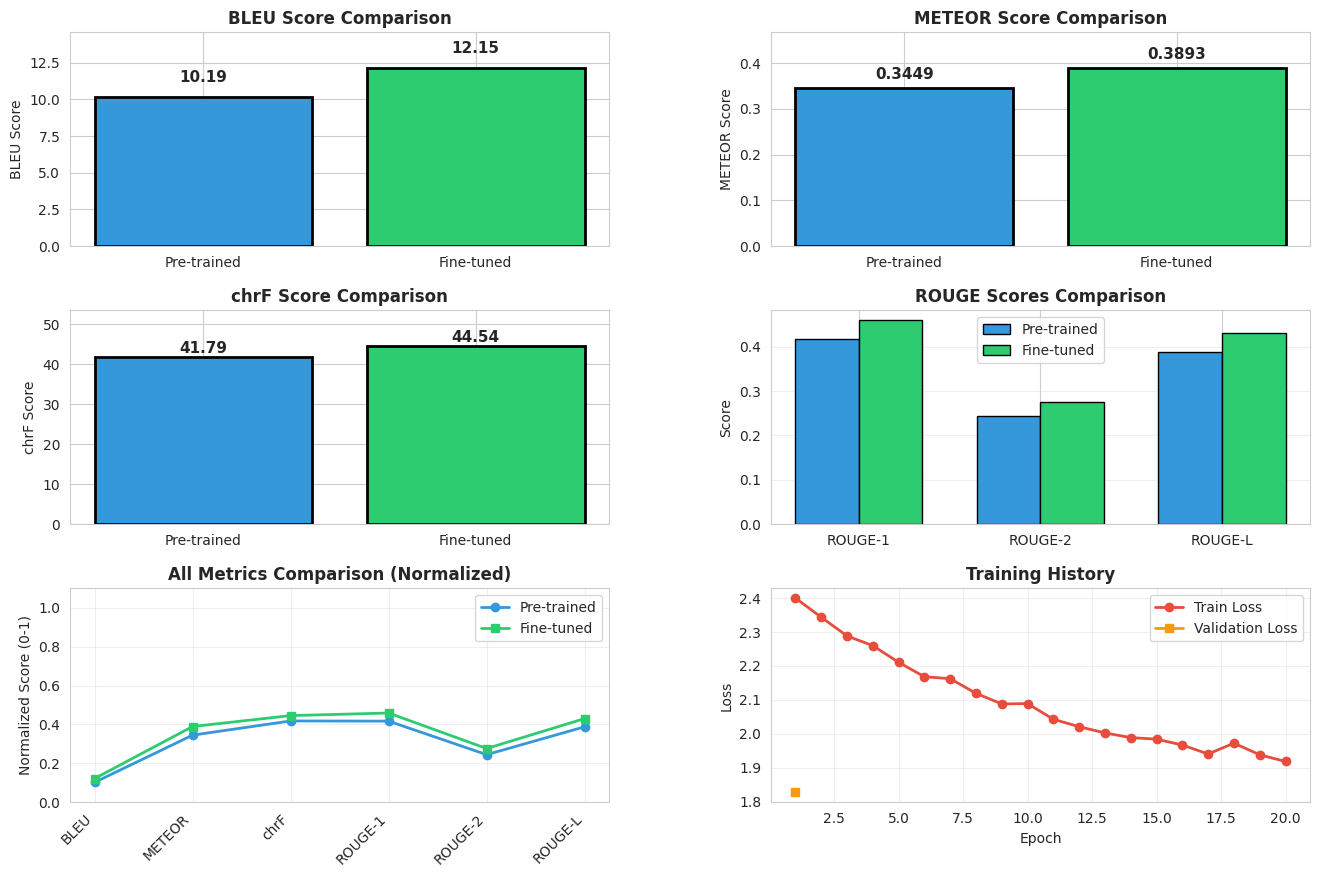


Saving results...

M2M100 EXPERIMENT COMPLETED!

Files saved:
  - m2m100_results.png (comprehensive visualization with all metrics)
  - m2m100_test_results.csv (detailed translations)
  - m2m100_summary.csv (all metrics summary)
  - Model saved in: ./m2m100-fr-tr-finetuned/final_model/

✓ Ready to proceed with the next model!


In [16]:
print("STEP 9: VISUALIZING RESULTS")
print("="*60)

# Create comparison plot with multiple metrics
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. BLEU Score comparison
ax1 = fig.add_subplot(gs[0, 0])
models = ['Pre-trained', 'Fine-tuned']
bleu_scores = [pretrained_bleu['score'], finetuned_bleu['score']]
colors = ['#3498db', '#2ecc71']
ax1.bar(models, bleu_scores, color=colors, edgecolor='black', linewidth=2)
ax1.set_title('BLEU Score Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('BLEU Score')
ax1.set_ylim(0, max(bleu_scores) * 1.2)
for i, v in enumerate(bleu_scores):
    ax1.text(i, v + 1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

# 2. METEOR Score comparison
ax2 = fig.add_subplot(gs[0, 1])
meteor_scores = [pretrained_meteor['meteor'], finetuned_meteor['meteor']]
ax2.bar(models, meteor_scores, color=colors, edgecolor='black', linewidth=2)
ax2.set_title('METEOR Score Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('METEOR Score')
ax2.set_ylim(0, max(meteor_scores) * 1.2)
for i, v in enumerate(meteor_scores):
    ax2.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)

# 3. chrF Score comparison
ax3 = fig.add_subplot(gs[1, 0])
chrf_scores = [pretrained_chrf['score'], finetuned_chrf['score']]
ax3.bar(models, chrf_scores, color=colors, edgecolor='black', linewidth=2)
ax3.set_title('chrF Score Comparison', fontsize=12, fontweight='bold')
ax3.set_ylabel('chrF Score')
ax3.set_ylim(0, max(chrf_scores) * 1.2)
for i, v in enumerate(chrf_scores):
    ax3.text(i, v + 1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

# 4. ROUGE Scores comparison
ax4 = fig.add_subplot(gs[1, 1])
rouge_metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
pretrained_rouge_scores = [pretrained_rouge['rouge1'], pretrained_rouge['rouge2'], pretrained_rouge['rougeL']]
finetuned_rouge_scores = [finetuned_rouge['rouge1'], finetuned_rouge['rouge2'], finetuned_rouge['rougeL']]
x = np.arange(len(rouge_metrics))
width = 0.35
ax4.bar(x - width/2, pretrained_rouge_scores, width, label='Pre-trained', color='#3498db', edgecolor='black')
ax4.bar(x + width/2, finetuned_rouge_scores, width, label='Fine-tuned', color='#2ecc71', edgecolor='black')
ax4.set_title('ROUGE Scores Comparison', fontsize=12, fontweight='bold')
ax4.set_ylabel('Score')
ax4.set_xticks(x)
ax4.set_xticklabels(rouge_metrics)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. All metrics comparison (radar chart style)
ax5 = fig.add_subplot(gs[2, 0])
all_metrics = ['BLEU', 'METEOR', 'chrF', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
# Normalize scores to 0-1 range for better visualization
pretrained_all = [
    pretrained_bleu['score']/100,
    pretrained_meteor['meteor'],
    pretrained_chrf['score']/100,
    pretrained_rouge['rouge1'],
    pretrained_rouge['rouge2'],
    pretrained_rouge['rougeL']
]
finetuned_all = [
    finetuned_bleu['score']/100,
    finetuned_meteor['meteor'],
    finetuned_chrf['score']/100,
    finetuned_rouge['rouge1'],
    finetuned_rouge['rouge2'],
    finetuned_rouge['rougeL']
]
x_pos = np.arange(len(all_metrics))
ax5.plot(x_pos, pretrained_all, marker='o', linewidth=2, label='Pre-trained', color='#3498db')
ax5.plot(x_pos, finetuned_all, marker='s', linewidth=2, label='Fine-tuned', color='#2ecc71')
ax5.set_title('All Metrics Comparison (Normalized)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Normalized Score (0-1)')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(all_metrics, rotation=45, ha='right')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_ylim(0, 1.1)

# 6. Training history
ax6 = fig.add_subplot(gs[2, 1])
if hasattr(trainer.state, 'log_history'):
    train_losses = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
    eval_losses = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

    epochs = range(1, len(train_losses) + 1)
    ax6.plot(epochs, train_losses[:len(epochs)], marker='o', label='Train Loss', color='#e74c3c', linewidth=2)
    if eval_losses:
        eval_epochs = range(1, len(eval_losses) + 1)
        ax6.plot(eval_epochs, eval_losses, marker='s', label='Validation Loss', color='#f39c12', linewidth=2)
    ax6.set_title('Training History', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel('Loss')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

plt.savefig('m2m100_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Save results to CSV
print("\nSaving results...")
test_subset.to_csv('m2m100_test_results.csv', index=False)

# Save summary
summary = {
    'Model': 'M2M100',
    'Pre-trained_BLEU': pretrained_bleu['score'],
    'Fine-tuned_BLEU': finetuned_bleu['score'],
    'BLEU_Improvement': finetuned_bleu['score'] - pretrained_bleu['score'],
    'Pre-trained_METEOR': pretrained_meteor['meteor'],
    'Fine-tuned_METEOR': finetuned_meteor['meteor'],
    'METEOR_Improvement': finetuned_meteor['meteor'] - pretrained_meteor['meteor'],
    'Pre-trained_chrF': pretrained_chrf['score'],
    'Fine-tuned_chrF': finetuned_chrf['score'],
    'chrF_Improvement': finetuned_chrf['score'] - pretrained_chrf['score'],
    'Pre-trained_ROUGE1': pretrained_rouge['rouge1'],
    'Fine-tuned_ROUGE1': finetuned_rouge['rouge1'],
    'ROUGE1_Improvement': finetuned_rouge['rouge1'] - pretrained_rouge['rouge1'],
    'Pre-trained_ROUGE2': pretrained_rouge['rouge2'],
    'Fine-tuned_ROUGE2': finetuned_rouge['rouge2'],
    'ROUGE2_Improvement': finetuned_rouge['rouge2'] - pretrained_rouge['rouge2'],
    'Pre-trained_ROUGEL': pretrained_rouge['rougeL'],
    'Fine-tuned_ROUGEL': finetuned_rouge['rougeL'],
    'ROUGEL_Improvement': finetuned_rouge['rougeL'] - pretrained_rouge['rougeL'],
    'Test_Samples': len(test_subset)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('m2m100_summary.csv', index=False)

print("\n" + "="*60)
print("M2M100 EXPERIMENT COMPLETED!")
print("="*60)
print(f"\nFiles saved:")
print(f"  - m2m100_results.png (comprehensive visualization with all metrics)")
print(f"  - m2m100_test_results.csv (detailed translations)")
print(f"  - m2m100_summary.csv (all metrics summary)")
print(f"  - Model saved in: ./m2m100-fr-tr-finetuned/final_model/")
print("\n✓ Ready to proceed with the next model!")